# Double Descent in High-Energy Physics

In many physics and machine-learning problems, increasing model complexity is expected to *eventually* hurt performance due to overfitting.

However, modern experiments repeatedly show a surprising behavior:

> Test error can *increase* near the point where a model first interpolates the training data —  
> and then *decrease again* as the model becomes even more complex.

This phenomenon is known as **double descent**.

In this tutorial, we will:
- observe double descent in simple and realistic settings,
- understand **why** it happens,
- and learn how to **test explanations** using *ablation*.

The goal is not to study a specific model class, but to learn a **general experimental method** that applies broadly across physics and machine learning.

## What you will learn

This notebook is **not** about polynomials, neural networks, or PDFs specifically.

Instead, it teaches a reusable scientific tool:

> **Ablation** — deliberately removing a suspected mechanism and checking whether a phenomenon disappears.

In this tutorial:
- The **phenomenon** is *double descent*
- The **suspected mechanism** is *amplification from small singular values*
- The **ablation** is a *spectral cutoff* that removes those small singular values

By the end, you should be able to:
1. Make double descent appear in a model of your choice
2. Form a hypothesis for *why* it appears
3. Test that hypothesis using ablation

In [1]:
import numpy as np
import scipy.special
import matplotlib.pyplot as plt
import os

# Set random seed for reproducibility
np.random.seed(0)

# Create results directory
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)

# ============================================================
# Global matplotlib style for publication-quality plots
# ============================================================

import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------- Font sizes ----------
BASE_FONT_SIZE   = 14
TITLE_FONT_SIZE  = 18
LABEL_FONT_SIZE  = 16
TICK_FONT_SIZE   = 13
LEGEND_FONT_SIZE = 13

# ---------- Line / marker defaults ----------
LINE_WIDTH   = 2.2
MARKER_SIZE  = 6

# ---------- Figure defaults ----------
FIG_WIDTH  = 10
FIG_HEIGHT = 7
DPI        = 120

mpl.rcParams.update({
    # Fonts
    "font.size": BASE_FONT_SIZE,
    "axes.titlesize": TITLE_FONT_SIZE,
    "axes.labelsize": LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,

    # Lines & markers
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,

    # Axes
    "axes.linewidth": 1.2,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    # Figure
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),
    "figure.dpi": DPI,

    # Legend
    "legend.frameon": True,
    "legend.framealpha": 0.9,

    # Savefig
    "savefig.bbox": "tight",
    "savefig.dpi": DPI,
})

print("Matplotlib global style loaded.")

Matplotlib global style loaded.


## Roadmap

We proceed in four stages:

1. **A toy example**  
   Make double descent appear in a simple regression problem.

1. **A real physics example (PDF fitting)**  
   Show that double descent survives realistic uncertainties.

2. **Homework**  
   Apply ablation yourself in a new setting.

## Part 1: Toy Example - Polynomial Regression

We'll fit a simple function with a polynomial basis and observe double descent at the interpolation threshold (where model degrees = number of training points).

In [2]:
# Ground truth function
def compute_y_from_x(X: np.ndarray):
    """Ground truth: linear trend + oscillatory component"""
    return np.add(2.0 * X, 1 * np.cos(X * 25))[:, 0]

In [3]:
# Parameters
num_pt_list = [15]  # Number of training points
num_features_list = [
    1,    2,    3,    4,    5,    6,    7,    8,    9,    10,    11,    12,    13,    14,    15,    16,    17,
    18,    19,    20,    21,    22,    23,    24,    25,    30,    40,    50,    100,    200,
]
n_replicas = 30  # Number of noise realizations
noise_level = 0.25  # Noise standard deviation
low, high = -1.0, 1.0

results_dir = "results/polynomial_regression"
os.makedirs(results_dir, exist_ok=True)

print(f"Training points: {num_pt_list[0]}")

Training points: 15


In [4]:
np.random.seed(0)

for num_pt in num_pt_list:
    results_num_pt_dir = os.path.join(results_dir, f"num_points={num_pt}")
    os.makedirs(results_num_pt_dir, exist_ok=True)

    # Generate test points.
    X_test  = np.linspace(start=low, stop=high, num=1000).reshape(-1, 1)
    y_test  = compute_y_from_x(X_test)
    y_test_ = y_test.reshape(1, -1, 1)  # Shape for broadcasting

    # Sample training points.
    X_train = np.random.uniform(low=low, high=high, size=(num_pt, 1))
    y_train_clean = compute_y_from_x(X_train)[:, None]  # (N,1)
    y_train = y_train_clean + np.random.normal(0, noise_level, size=(num_pt, n_replicas))
    
    y_train_pred = []
    y_test_pred  = []
    
    for num_features in num_features_list:
        feature_degrees = np.arange(num_features).astype(int)  # 0,1,2,...,M-1
        Xtr = X_train[:, 0]
        Xte = X_test[:, 0]

        X_train_poly = scipy.special.eval_legendre(feature_degrees[:, None], Xtr[None, :]).T  # (N_train, M)
        X_test_poly  = scipy.special.eval_legendre(feature_degrees[:, None], Xte[None, :]).T  # (N_test,  M)
        beta_hat = np.linalg.pinv(X_train_poly) @ y_train
        y_train_pred.append(X_train_poly @ beta_hat)
        y_test_pred.append(X_test_poly @ beta_hat)
    
    y_train_pred = np.array(y_train_pred)
    y_test_pred = np.array(y_test_pred)

In [5]:
# Compute MSE (Mean Squared Error)
train_error = np.mean((y_train - y_train_pred)**2, axis=1)
train_error_mean = np.mean(train_error, axis=1)
train_error_std  = np.std(train_error, axis=1)

test_error = np.mean((y_test_ - y_test_pred)**2, axis=1)
test_error_mean = np.mean(test_error, axis=1)
test_error_std  = np.std(test_error, axis=1)

print(f"Train error shape: {train_error.shape}")
print(f"Test error shape: {test_error.shape}")

Train error shape: (30, 30)
Test error shape: (30, 30)


### How the fitted functions change with model complexity

To better understand double descent, it helps to look directly at the fitted functions.

Below, we visualize three representative regimes:
- **Underfitting**: too few parameters to capture the structure of the data
- **Interpolation threshold**: just enough parameters to fit the training data
- **Overparameterized**: many more parameters than data points

Each panel shows multiple fitted models corresponding to different noise realizations.

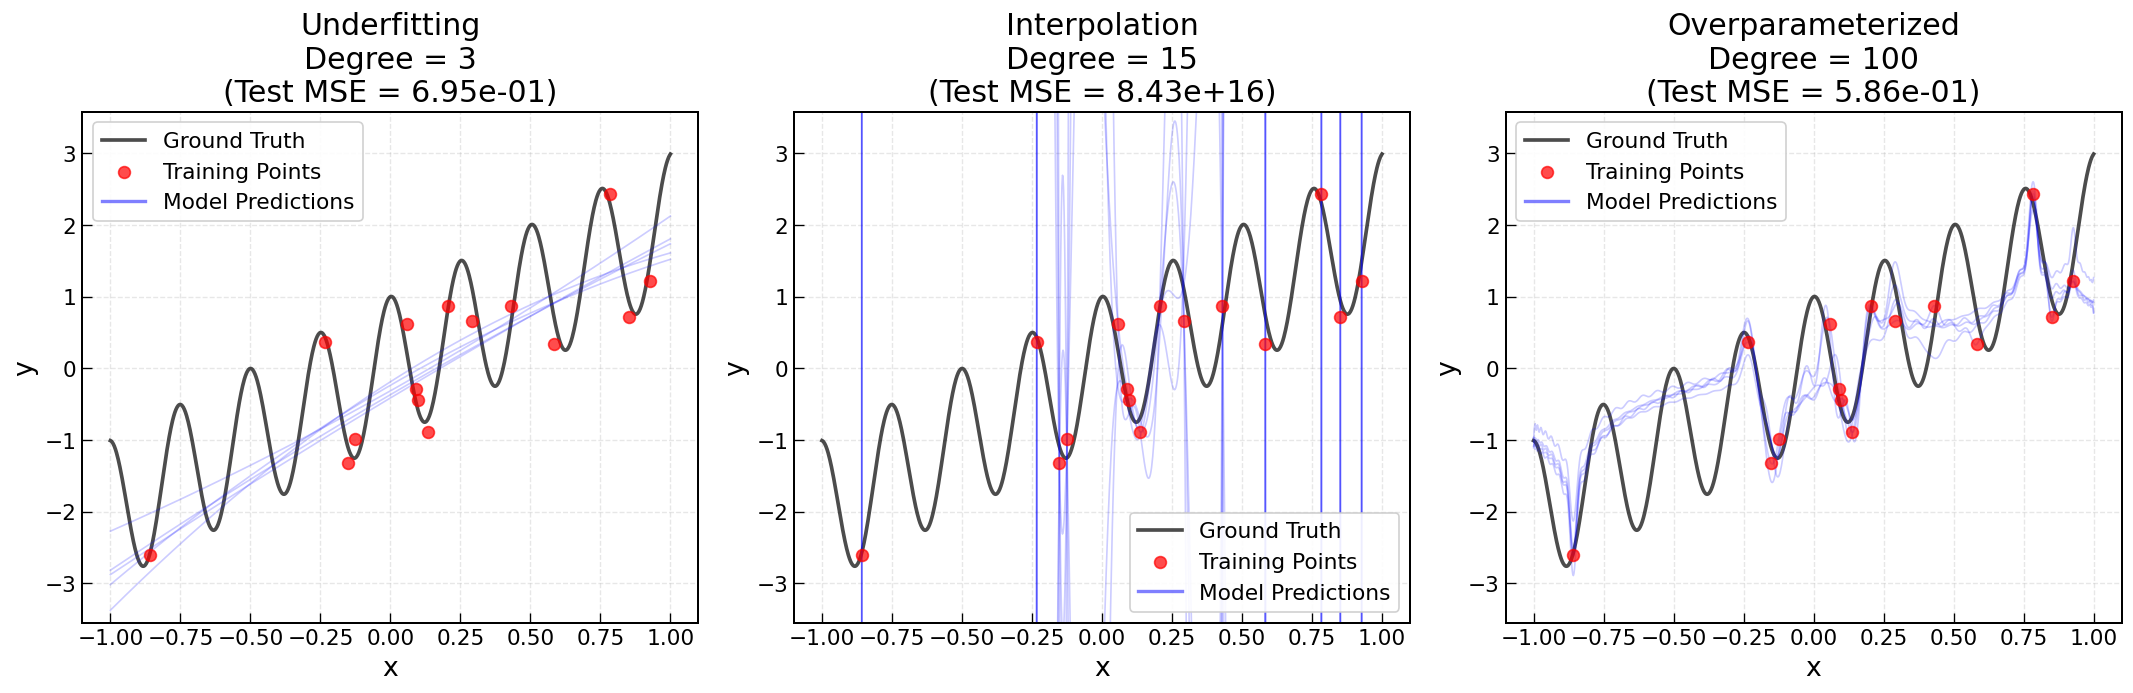

In [6]:
# ============================================================
# Visualize fits at key degrees
# ============================================================

degrees_to_show = [3, num_pt_list[0], 100]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# pick first replica if y_train has replicas
y_train_show = y_train if y_train.ndim == 1 else y_train[:, 0]

# consistent y-limits across panels
y_ref = np.r_[y_test.ravel(), y_train_show.ravel()]
y_min, y_max = np.percentile(y_ref, [1, 99])
pad = 0.15 * (y_max - y_min if y_max > y_min else 1.0)
y_min -= pad
y_max += pad

for ax, degree in zip(axes, degrees_to_show):
    idx = num_features_list.index(degree)

    # ground truth + training points
    ax.plot(X_test, y_test, "k-", alpha=0.7, label="Ground Truth")
    ax.scatter(X_train, y_train_show, c="red", s=50, alpha=0.7,
               zorder=5, label="Training Points")

    # predictions (ensure 2D: (N_test, R))
    pred = y_test_pred[idx]
    if pred.ndim == 1:
        pred = pred[:, None]

    for rep in range(min(5, pred.shape[1])):
        ax.plot(X_test, pred[:, rep], "b-", alpha=0.2, lw=1)

    # one legend entry for predictions
    ax.plot([], [], "b-", alpha=0.5, lw=2, label="Model Predictions")

    # title + labels
    regime = "Underfitting" if degree < num_pt_list[0] else \
             "Interpolation" if degree == num_pt_list[0] else \
             "Overparameterized"

    ax.set_title(f"{regime}\nDegree = {degree}\n(Test MSE = {test_error_mean[idx]:.2e})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_ylim(y_min, y_max)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

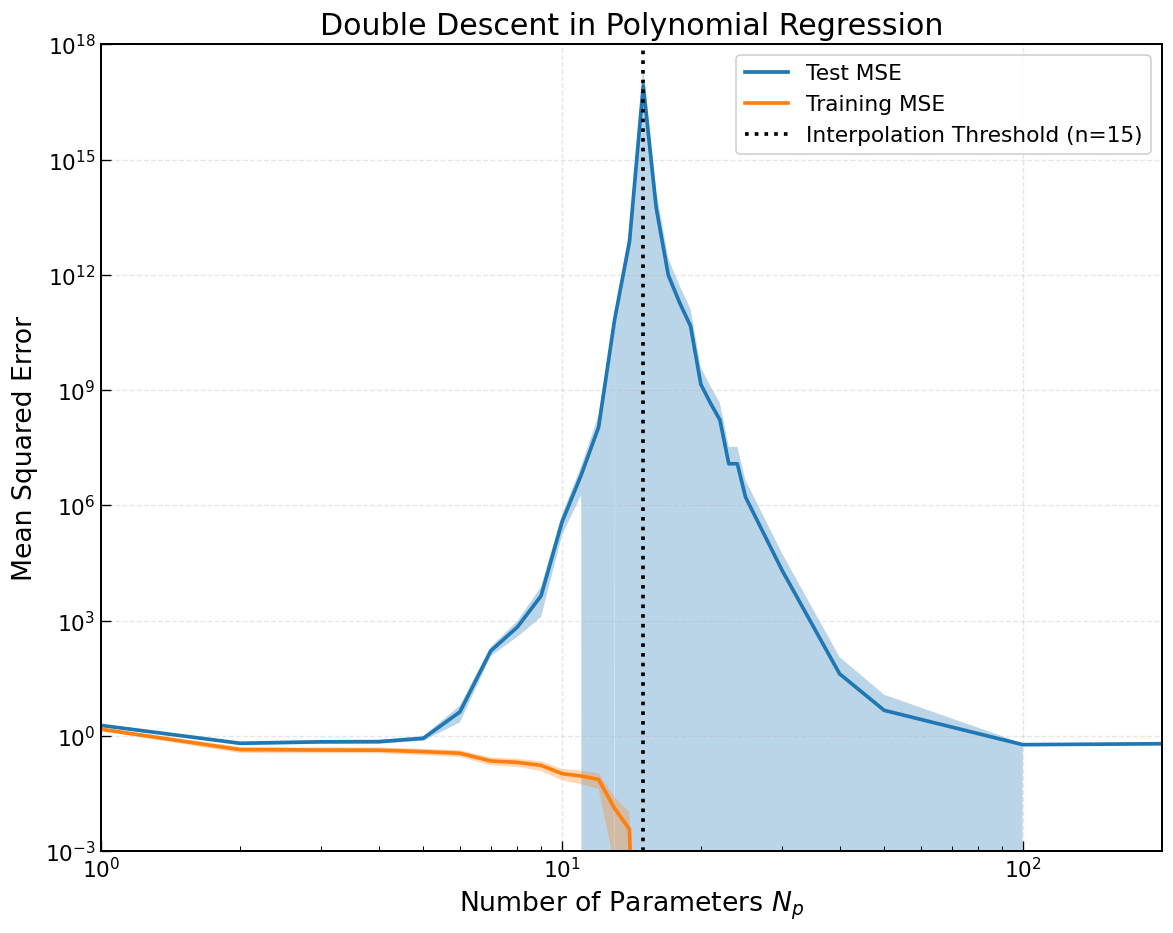


Peak test error occurs near degree = 15
This is at the interpolation threshold where model capacity = training points


In [7]:
# Plot double descent curve
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Test error
ax.plot(num_features_list, test_error_mean, label='Test MSE')
ax.fill_between(num_features_list, 
                test_error_mean - test_error_std,
                test_error_mean + test_error_std,
                alpha=0.3)

# Training error
ax.plot(num_features_list, train_error_mean, label='Training MSE')
ax.fill_between(num_features_list, 
                train_error_mean - train_error_std,
                train_error_mean + train_error_std,
                alpha=0.3)

# Interpolation threshold
ax.axvline(num_pt_list[0], color='k', linestyle=':', 
           label=f'Interpolation Threshold (n={num_pt_list[0]})')

ax.set_xlabel('Number of Parameters $N_p$')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Double Descent in Polynomial Regression')
ax.legend(loc='best')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-3, 1e18)
ax.set_xlim(min(num_features_list), max(num_features_list))
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"\nPeak test error occurs near degree = {num_features_list[np.argmax(test_error_mean)]}")
print(f"This is at the interpolation threshold where model capacity = training points")

### What should you notice?

- Training error decreases monotonically as model complexity increases.
- Test error initially decreases, then **peaks sharply** near the interpolation threshold.
- After interpolation, test error **decreases again**, despite the model having *more parameters than data points*.

This non-monotonic behavior of the test error is called **double descent**.

The peak occurs when the model is just powerful enough to interpolate the training data.

Here, *interpolation* means that the model fits the training data essentially exactly (training error ≈ 0).

In [8]:
# ============================================================
# CODING GAP: Make double descent appear (your choice)
# Fill in the TODOs below. When you're done, you should get a
# double-descent curve (test error peaks near interpolation).
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ----------------------------
# 1) Data generator (given)
# ----------------------------
def f_true(x):
    # You can change this if you want, but keep it 1D for now.
    return 2.0 * x + np.cos(25.0 * x)

N_train = 15
N_test  = 500
noise_level = 0.25

x_train = np.random.uniform(-1, 1, size=(N_train, 1))
y_train_clean = f_true(x_train[:, 0])
y_train = y_train_clean * (1.0 + np.random.normal(0, noise_level, size=N_train))

x_test = np.linspace(-1, 1, N_test).reshape(-1, 1)
y_test_clean = f_true(x_test[:, 0])

# ----------------------------
# 2) Choose model complexity sweep
# ----------------------------
P_list = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,25,30,40,60,100]

# ----------------------------
# 3) TODO: Feature map phi(x, P)
# ----------------------------
def design_matrix(x, P):
    """
    Return X with shape (N, P).
    TODO: implement a feature map whose complexity increases with P.
    
    Options (pick one):
      A) monomials: [1, x, x^2, ..., x^(P-1)]
      B) Legendre: [P0(x), P1(x), ..., P_{P-1}(x)]
      C) random features: [cos(w_k x + b_k)] with k=1..P  (keep w,b fixed!)
    """
    # TODO: replace this line
    raise NotImplementedError("Fill in design_matrix(x, P)")

# Hint: if you choose monomials, start with:
# X = np.ones((len(x), P))
# for k in range(1, P):
#     X[:, k] = x[:, 0]**k
# return X

# ----------------------------
# 4) Fit/predict helper (given)
# ----------------------------
def fit_and_predict(x_train, y_train, x_eval, P):
    Xtr = design_matrix(x_train, P)        # (N_train, P)
    Xev = design_matrix(x_eval,  P)        # (N_eval,  P)

    # least squares via pseudoinverse (works in under/overparameterized regimes)
    beta = np.linalg.pinv(Xtr) @ y_train   # (P,)
    return Xev @ beta                      # (N_eval,)

# ----------------------------
# 5) Compute train/test MSE vs P
# ----------------------------
train_mse = []
test_mse  = []

for P in P_list:
    yhat_train = fit_and_predict(x_train, y_train, x_train, P)
    yhat_test  = fit_and_predict(x_train, y_train, x_test,  P)

    train_mse.append(np.mean((y_train - yhat_train)**2))
    test_mse.append(np.mean((y_test_clean - yhat_test)**2))

train_mse = np.array(train_mse)
test_mse  = np.array(test_mse)

# ----------------------------
# 6) Plot (given)
# ----------------------------
plt.figure(figsize=(8,6))
plt.plot(P_list, test_mse,  label="Test MSE")
plt.plot(P_list, train_mse, label="Train MSE")
plt.axvline(N_train, linestyle=":", color="k", label=f"Interpolation (~N_train={N_train})")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Model complexity P")
plt.ylabel("MSE")
plt.title("Your Double Descent Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Peak test MSE at P =", P_list[int(np.argmax(test_mse))])

NotImplementedError: Fill in design_matrix(x, P)

## Part 2: LHAPDF Parametrization

### How the fitted functions change with model complexity

To better understand double descent, it helps to look directly at the fitted functions.

Below, we visualize three representative regimes:
- **Underfitting**: too few parameters to capture the structure of the data
- **Interpolation threshold**: just enough parameters to fit the training data
- **Overparameterized**: many more parameters than data points

Each panel shows multiple fitted models corresponding to different noise realizations.

In [20]:
try:
    import lhapdf
    LHAPDF_AVAILABLE = True
    print("LHAPDF is available")
except ImportError:
    LHAPDF_AVAILABLE = False
    print("LHAPDF not available. Install with: pip install lhapdf")
    print("Continuing with synthetic PDF-like function...")


pdf_name = "NNPDF31_nnlo_as_0118"

pdf = lhapdf.mkPDF(pdf_name, 0)
Q2 = 10  # GeV^2
print(f"Loaded {pdf_name}")
print(f"Using gluon PDF (flavor=21) at Q^2 = {Q2} GeV^2")
        
def pdf_function(X: np.ndarray, Q2=10.0, flavor=21):
    """Evaluate PDF at given x, Q^2, and flavor (21=gluon)"""
    xvals = X[:, 0]
    return np.array([pdf.xfxQ2(flavor, float(x), Q2) for x in xvals])

LHAPDF is available
LHAPDF 6.5.5 loading /opt/anaconda3/share/LHAPDF/NNPDF31_nnlo_as_0118/NNPDF31_nnlo_as_0118_0000.dat
Loaded NNPDF31_nnlo_as_0118
Using gluon PDF (flavor=21) at Q^2 = 10 GeV^2
NNPDF31_nnlo_as_0118 PDF set, member #0, version 1; LHAPDF ID = 303600


In [21]:
# Parameters for PDF fitting
num_pt_list_pdf = [15]  # Number of training points
num_features_list_pdf = [
    1,    2,    3,    4,    5,    6,    7,    8,    9,    10,    11,    12,    13,    14,    15,    16,    17,
    18,    19,    20,    21,    22,    23,    24,    25,    30,    40,    50,    100,    200,
]
n_replicas_pdf = 30  # Noise realizations
noise_level_pdf = 0.25  # 25% noise

num_total = 100  # Total points sampled from PDF

# Sample x values (log-uniform in x, typical for PDFs)
x_min, x_max = 1e-3, 0.9

results_dir_pdf = "results/pdf_regression"
os.makedirs(results_dir_pdf, exist_ok=True)

print(f"Training on {num_pt_list_pdf[0]} points")
print(f"Total available points: {num_total}")
print(f"Validation points: {num_total - num_pt_list_pdf[0]}")

Training on 15 points
Total available points: 100
Validation points: 85


In [23]:
# ============================================================
# LHAPDF / PDF fit — CODE CELL (fit once, store preds)
# Produces:
#   y_train_pdf_pred: (len(P_list), N_train, R)
#   y_test_pdf_pred : (len(P_list), N_test,  R)
# Also creates noisy observed targets on BOTH train/test:
#   y_train_pdf_obs, y_test_pdf_obs
# ============================================================

import numpy as np
import scipy.special

# ----------------------------
# 0) Reproducibility
# ----------------------------
SEED = 0
rng = np.random.default_rng(SEED)

# ----------------------------
# 1) Settings
# ----------------------------
num_total = 100
x_min, x_max = 1e-3, 0.9

num_pt_pdf = num_pt_list_pdf[0]            # e.g. 15
P_list     = list(num_features_list_pdf)   # sweep over basis size
R          = n_replicas_pdf                # number of noise replicas
rel_noise  = noise_level_pdf               # e.g. 0.25 (multiplicative)

# Use a numerically sane pseudoinverse cutoff for baseline fits
PINV_RCOND = 1e-12

# ----------------------------
# 2) Sample x grid and truth
# ----------------------------
x_all = np.logspace(np.log10(x_min), np.log10(x_max), num_total).reshape(-1, 1)
y_pdf_all = pdf_function(x_all, Q2=Q2, flavor=21)  # NOTE: x*f(x,Q2) from LHAPDF (xg for gluon)

# ----------------------------
# 3) Train/test split
# ----------------------------
train_indices = rng.choice(num_total, size=num_pt_pdf, replace=False)
test_indices  = np.setdiff1d(np.arange(num_total), train_indices)

x_train_pdf = x_all[train_indices]
y_train_pdf_true = y_pdf_all[train_indices]   # (N_train,)

x_test_pdf = x_all[test_indices]
y_test_pdf_true  = y_pdf_all[test_indices]    # (N_test,)

# ----------------------------
# 4) Noise replicas on BOTH train and test (multiplicative)
# ----------------------------
y_train_pdf_obs = y_train_pdf_true[:, None] * (1.0 + rng.normal(0, rel_noise, size=(len(y_train_pdf_true), R)))
y_test_pdf_obs  = y_test_pdf_true[:,  None] * (1.0 + rng.normal(0, rel_noise, size=(len(y_test_pdf_true),  R)))
# shapes: (N_train, R), (N_test, R)

# ----------------------------
# 5) Transform log(x) -> [-1, 1]
# ----------------------------
log_x_min, log_x_max = np.log(x_min), np.log(x_max)

def transform_x(x):
    log_x = np.log(x)
    return 2.0 * (log_x - log_x_min) / (log_x_max - log_x_min) - 1.0

x_train_t = transform_x(x_train_pdf)  # (N_train, 1)
x_test_t  = transform_x(x_test_pdf)   # (N_test,  1)

# ----------------------------
# 6) Legendre basis + fit helper (optionally with SVD cutoff)
# ----------------------------
def legendre_design(x_t, P):
    degrees = np.arange(P, dtype=int)  # includes degree 0
    z = x_t.ravel()
    return np.column_stack([scipy.special.eval_legendre(d, z) for d in degrees])  # (N, P)

def fit_legendre(X_train_t, y_train, X_eval_t, P, *, rcond=PINV_RCOND, svd_cutoff=None):
    """
    y_train: (N_train, R)
    returns: (N_eval, R)
    """
    Xtr = legendre_design(X_train_t, P)  # (N_train, P)
    Xev = legendre_design(X_eval_t,  P)  # (N_eval,  P)

    if svd_cutoff is None:
        beta = np.linalg.pinv(Xtr, rcond=rcond) @ y_train  # (P, R)
    else:
        U, S, Vt = np.linalg.svd(Xtr, full_matrices=False)
        keep = S >= svd_cutoff
        if not np.any(keep):
            return np.zeros((Xev.shape[0], y_train.shape[1]))
        beta = (Vt[keep].T / S[keep]) @ (U[:, keep].T @ y_train)  # (P, R)

    return Xev @ beta  # (N_eval, R)

# ----------------------------
# 7) Fit once across P
# ----------------------------
y_train_pdf_pred = []
y_test_pdf_pred  = []
y_plot_pdf_pred  = []   

# Transform the dense grid for plotting!
x_all_t = transform_x(x_all) 

for P in P_list:
    # Train on noisy replicas, evaluate on train/test/dense grid
    y_train_pdf_pred.append(fit_legendre(x_train_t, y_train_pdf_obs, x_train_t, P))
    y_test_pdf_pred.append(fit_legendre(x_train_t, y_train_pdf_obs, x_test_t, P))
    
    # FIX: Pass x_all_t (the transformed grid) here
    y_plot_pdf_pred.append(fit_legendre(x_train_t, y_train_pdf_obs, x_all_t, P))

y_train_pdf_pred = np.array(y_train_pdf_pred)
y_test_pdf_pred  = np.array(y_test_pdf_pred)
y_plot_pdf_pred  = np.array(y_plot_pdf_pred)

print("Shapes:",
      "\n  x_train_pdf       ", x_train_pdf.shape,
      "\n  y_train_pdf_true  ", y_train_pdf_true.shape,
      "\n  y_train_pdf_obs   ", y_train_pdf_obs.shape,
      "\n  y_train_pdf_pred  ", y_train_pdf_pred.shape,
      "\n  x_test_pdf        ", x_test_pdf.shape,
      "\n  y_test_pdf_true   ", y_test_pdf_true.shape,
      "\n  y_test_pdf_obs    ", y_test_pdf_obs.shape,
      "\n  y_test_pdf_pred   ", y_test_pdf_pred.shape,
      "\n  y_plot_pdf_pred   ", y_plot_pdf_pred.shape)

Shapes: 
  x_train_pdf        (15, 1) 
  y_train_pdf_true   (15,) 
  y_train_pdf_obs    (15, 30) 
  y_train_pdf_pred   (30, 15, 30) 
  x_test_pdf         (85, 1) 
  y_test_pdf_true    (85,) 
  y_test_pdf_obs     (85, 30) 
  y_test_pdf_pred    (30, 85, 30) 
  y_plot_pdf_pred    (30, 100, 30)


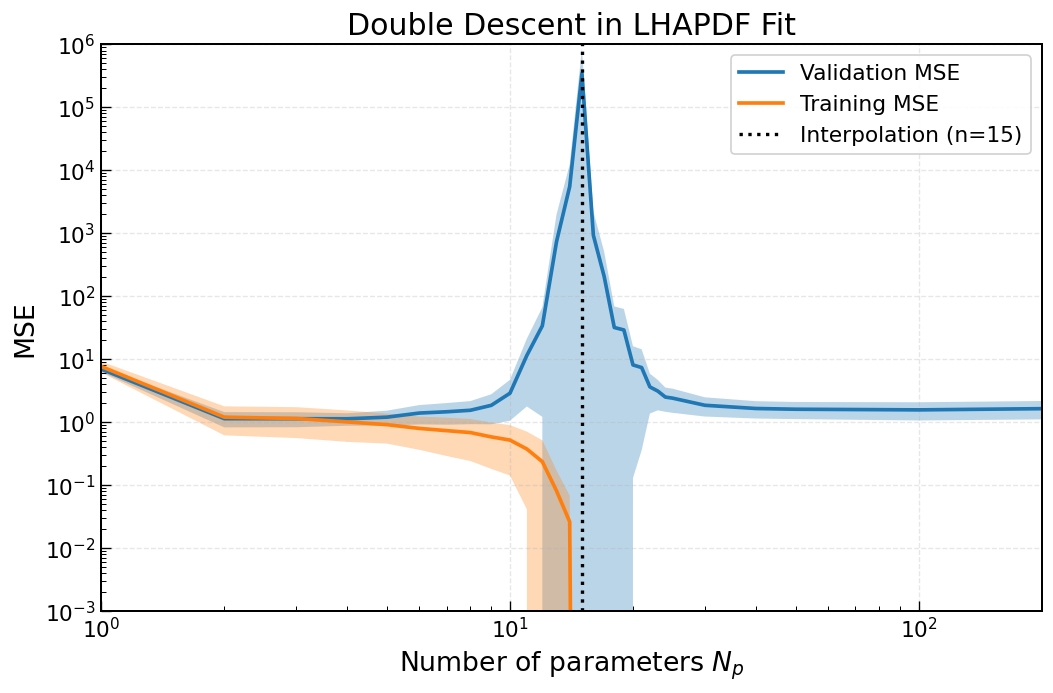

Peak validation MSE at P = 15


In [24]:
import numpy as np
import matplotlib.pyplot as plt

P_list = np.array(P_list)

train_mse = np.mean((y_train_pdf_pred - y_train_pdf_obs[None, :, :])**2, axis=1)  # (P, R)
test_mse  = np.mean((y_test_pdf_pred  - y_test_pdf_obs[None, :, :])**2, axis=1)   # (P, R)

train_mse_mean, train_mse_std = train_mse.mean(axis=1), train_mse.std(axis=1)
test_mse_mean,  test_mse_std  = test_mse.mean(axis=1),  test_mse.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(P_list, test_mse_mean, label="Validation MSE")
ax.fill_between(P_list, test_mse_mean - test_mse_std, test_mse_mean + test_mse_std, alpha=0.3)

ax.plot(P_list, train_mse_mean, label="Training MSE")
ax.fill_between(P_list, train_mse_mean - train_mse_std, train_mse_mean + train_mse_std, alpha=0.3)

ax.axvline(num_pt_pdf, color="k", linestyle=":", linewidth=2, label=f"Interpolation (n={num_pt_pdf})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1E-3, 1E6)
ax.set_xlim(min(num_features_list), max(num_features_list))
ax.set_xlabel("Number of parameters $N_p$")
ax.set_ylabel("MSE")
ax.set_title("Double Descent in LHAPDF Fit")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Peak validation MSE at P =", int(P_list[np.argmax(test_mse_mean)]))

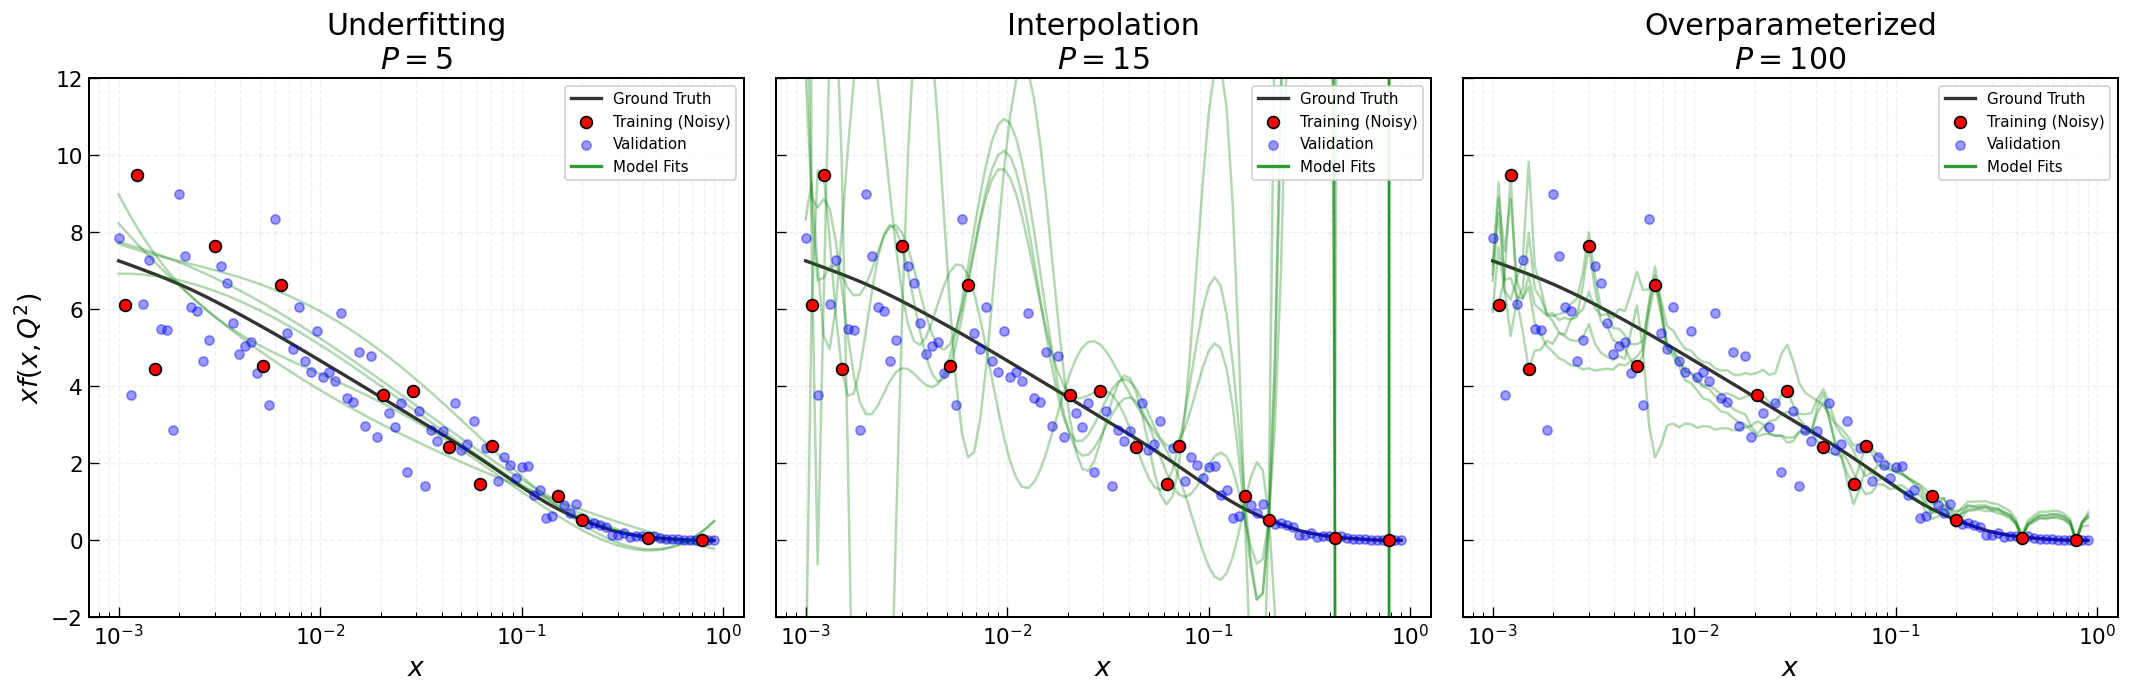

In [ ]:
# ============================================================
# FINAL CORRECTED: Visualize LHAPDF fits at key P
# ============================================================

# 1. Setup the figure and key P values
degrees_pdf_to_show = [5, num_pt_list_pdf[0], 100]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Use first replica for dots
y_train_show = y_train_pdf_obs[:, 0]
y_test_show  = y_test_pdf_obs[:, 0]

# Sorting index for the dense grid (original scale)
sort_all = np.argsort(x_all.ravel())
x_plot_sorted = x_all.ravel()[sort_all]
y_truth_sorted = y_pdf_all[sort_all]

for ax, P in zip(axes, degrees_pdf_to_show):
    idx = num_features_list_pdf.index(P)
    
    # --- PLOT POINTS AND TRUTH ---
    ax.plot(x_plot_sorted, y_truth_sorted, "k-", alpha=0.8, lw=2, label="Ground Truth")
    ax.scatter(x_train_pdf, y_train_show, c="red", s=50, edgecolors='k', 
               zorder=5, label="Training (Noisy)")
    ax.scatter(x_test_pdf, y_test_show, c="blue", s=30, alpha=0.4, 
               zorder=4, label="Validation")

    # --- PLOT PREDICTIONS (THE GREEN LINES) ---
    pred = y_plot_pdf_pred[idx] # Shape: (N_plot, R)
    
    for rep in range(min(5, pred.shape[1])):
        y_plot_sorted = pred[sort_all, rep]
        ax.plot(x_plot_sorted, y_plot_sorted, "g-", alpha=0.3, lw=1.5)

    # Proxy artist for legend
    ax.plot([], [], "g-", alpha=0.8, lw=2, label="Model Fits")

    # --- FORMATTING ---
    regime = "Underfitting" if P < num_pt_pdf else \
             "Interpolation" if P == num_pt_pdf else \
             "Overparameterized"
    
    ax.set_title(f"{regime}\n$P = {P}$")
    ax.set_xscale("log")
    ax.set_xlabel("$x$")
    if ax == axes[0]: ax.set_ylabel(r"$x f(x, Q^2)$")
    
    # Force y-limits to be reasonable so spikes don't flatten the rest of the plot
    ax.set_ylim(-2, 12) 
    ax.grid(True, which="both", alpha=0.2)
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

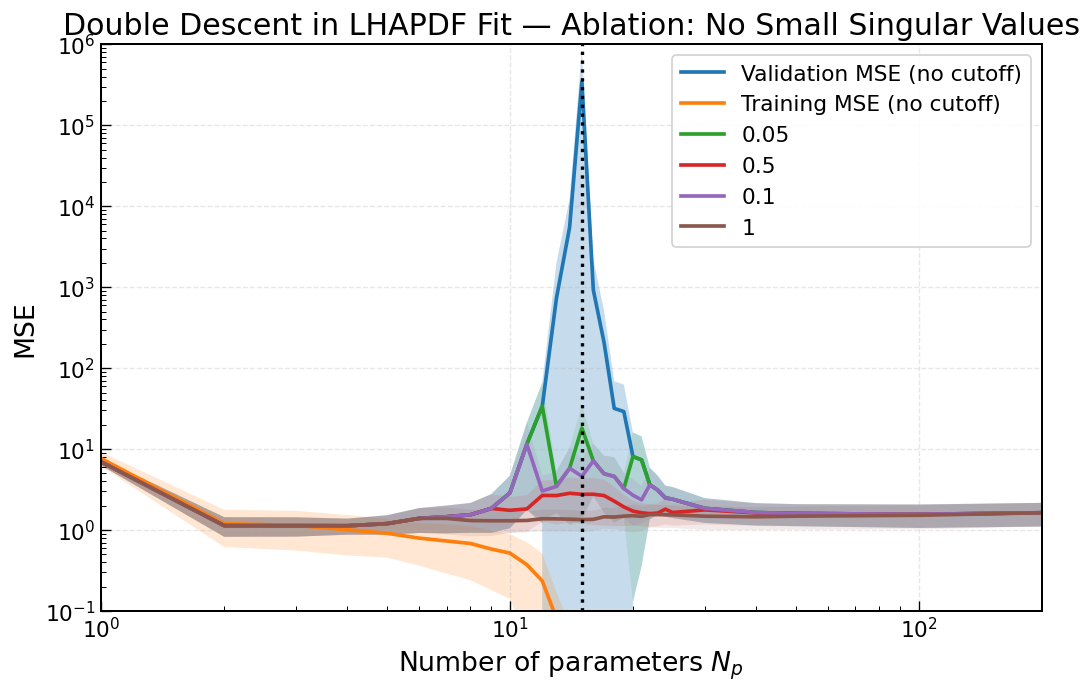

In [27]:
# ============================================================
# ABLATION: No Small Singular Values
# ============================================================

P_arr = np.array(P_list)

# Singular value cutoffs applied directly
singular_value_cutoffs = [5e-2, 5e-1, 1e-1, 1.0]

def predict_with_abs_svd_cutoff(X_train_t, y_train, X_eval_t, P, cutoff, rcond=PINV_RCOND):
    Xtr = legendre_design(X_train_t, P)  # (N_train, P)
    Xev = legendre_design(X_eval_t,  P)  # (N_eval,  P)

    # baseline (unablated)
    if cutoff is None:
        beta = np.linalg.pinv(Xtr, rcond=rcond) @ y_train
        return Xev @ beta

    U, S, Vt = np.linalg.svd(Xtr, full_matrices=False)

    S_cut = S.copy()
    S_cut[S_cut < cutoff] = 0.0

    inv_S = np.zeros_like(S_cut)
    nz = S_cut > 0.0
    inv_S[nz] = 1.0 / S_cut[nz]

    beta = Vt.T @ np.diag(inv_S) @ (U.T @ y_train)  # (P, R)
    return Xev @ beta                               # (N_eval, R)

# ---- Compute baseline once (optional: show training too) ----
y_train_pred_base = np.array([predict_with_abs_svd_cutoff(x_train_t, y_train_pdf_obs, x_train_t, P, None)
                              for P in P_list])
y_test_pred_base  = np.array([predict_with_abs_svd_cutoff(x_train_t, y_train_pdf_obs, x_test_t,  P, None)
                              for P in P_list])

train_mse_base = np.mean((y_train_pred_base - y_train_pdf_obs[None, :, :])**2, axis=1)
test_mse_base  = np.mean((y_test_pred_base  - y_test_pdf_obs[None,  :, :])**2, axis=1)

train_mean_base, train_std_base = train_mse_base.mean(axis=1), train_mse_base.std(axis=1)
test_mean_base,  test_std_base  = test_mse_base.mean(axis=1),  test_mse_base.std(axis=1)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9, 6))

# Baseline curves (match your favorite plot: both train + val)
ax.plot(P_arr, test_mean_base, label="Validation MSE (no cutoff)")
ax.fill_between(P_arr, test_mean_base - test_std_base, test_mean_base + test_std_base, alpha=0.25)

ax.plot(P_arr, train_mean_base, label="Training MSE (no cutoff)")
ax.fill_between(P_arr, train_mean_base - train_std_base, train_mean_base + train_std_base, alpha=0.18)

# Ablated validation curves for each cutoff
for cutoff in singular_value_cutoffs:
    y_test_pred_cut = np.array([
        predict_with_abs_svd_cutoff(x_train_t, y_train_pdf_obs, x_test_t, P, cutoff)
        for P in P_list
    ])  # (len(P_list), N_test, R)

    test_mse_cut = np.mean((y_test_pred_cut - y_test_pdf_obs[None, :, :])**2, axis=1)  # (P,R)
    test_mean, test_std = test_mse_cut.mean(axis=1), test_mse_cut.std(axis=1)

    ax.plot(P_arr, test_mean, label=f"{cutoff:g}")
    ax.fill_between(P_arr, test_mean - test_std, test_mean + test_std, alpha=0.12)

ax.axvline(num_pt_pdf, color="k", linestyle=":", linewidth=2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-1, 1e6)
ax.set_xlim(P_arr.min(), P_arr.max())
ax.set_xlabel("Number of parameters $N_p$")
ax.set_ylabel("MSE")
ax.set_title("Double Descent in LHAPDF Fit — Ablation: No Small Singular Values")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Why Small Singular Values Matter

We now summarize the spectral mechanism behind double descent.

Starting from the linear model,

$$
D = X \mathbf{a}^* + E,
$$

the least-squares estimator is

$$
\mathbf{a}_{\text{fit}} = (X^T X)^{-1} X^T D_{\text{train}}.
$$

Using the singular value decomposition (SVD),

$$
X = U \Sigma V^T,
$$

the variance contribution to the test error can be expressed in the singular basis as

$$
\text{Variance}
=
\sum_{r=1}^{R}
\frac{1}{\sigma_r}
(\mathbf{v}_r \cdot \mathbf{x})
(\mathbf{u}_r \cdot \mathbf{E}),
$$

where $ \sigma_r $ are the singular values of the observation matrix $X$.

This expression makes the mechanism clear. Each direction contributes inversely proportional to its singular value. Directions with large singular values are well constrained and stable. Directions with small singular values amplify noise. Extremely small singular values dominate the variance.

As the number of parameters approaches the number of training samples,

$$
N_{\text{parameters}} \approx N_{\text{train}},
$$

the smallest non-zero singular value of $X$ collapses. In that limit the inverse $1/\sigma_r$ becomes large and the variance explodes. This produces the double descent spike.

In the overparameterized regime,

$$
N_{\text{parameters}} \gg N_{\text{train}},
$$

the singular spectrum spreads out and typical singular values increase again. The variance shrinks and the test error decreases, producing the second descent. Double descent is therefore a spectral instability of the observation matrix. It is not simply a story about model size. It is a story about amplification along weakly constrained directions.

### What the Ablation Demonstrated

When we removed singular values below a cutoff,

$$
\sigma_r < \text{cutoff} \;\Rightarrow\; 0,
$$

we eliminated the unstable directions responsible for amplification. As a result, the spike shrank or disappeared. This confirms that small singular values are the mechanism driving the phenomenon. The ablation isolates that mechanism and tests it directly.
Please be advised that other methods of ablation exists (projecting test features into the training space, no noise in training data, ...), but are unsuitable for our example.

---

## Time-Permitting / Homework Exercise

To deepen your understanding, replicate this ablation in a toy model of your choice.

Construct a regression problem that exhibits double descent. Plot training and test error as a function of model complexity. Compute the singular values of the design matrix and observe how the smallest singular value behaves near interpolation. Apply a hard cutoff to the singular values and recompute the solution. Compare the curves before and after ablation.

Examine whether the smallest singular values collapse near interpolation. Determine whether removing them shrinks the spike. Investigate whether hard truncation produces multiple smaller spikes. Compare the effect of hard cutoff to smooth regularization such as ridge regression.

---

## Takeaway

Double descent is governed by the spectrum of the observation matrix. The smallest singular values determine stability. When they collapse, variance explodes. When they are controlled, the instability disappears. Understanding singular values means understanding when and why models become unstable across physics and machine learning.

In [15]:
### YOUR CODE HERE: Try other ablations to see what breaks double descent!



## Credits & References

### Academic Citation
The discussion of the **Double Descent** phenomenon, the spectral bias of linear models, and the use of ablation studies in this tutorial is informed by the research presented in:

> **Schaeffer, R., Khona, M., Robertson, Z., Boopathy, A., Pistunova, K., Rocks, J. W., Fiete, I. R., & Koyejo, O. (2023).** *Double Descent Demystified: Identifying, Interpreting & Ablating the Sources of a Deep Learning Puzzle.* [arXiv:2303.14151](https://arxiv.org/abs/2303.14151) [cs.LG].

This tutorial specifically adapts the **"General Experimental Method"** of ablation—deliberately removing a suspected mechanism (small singular values) to verify its role in the double descent phenomenon.

### Acknowledgments
The author would like to express sincere gratitude to **Daniel Adamiak** and **Dr. Pavel Nadolsky** for their invaluable support, guidance, and technical insights provided during the development of this tutorial.

### AI Attribution
Generative AI (Gemini 3 Flash) was utilized during the development of this notebook to assist with code debugging, mathematical formatting (LaTeX), and the structural organization of the tutorial content.